# Encoding Results 分析

本脚本读取所有模型的 encoding results 并进行初步分析


In [61]:
import numpy as np
import pandas as pd
import pickle
import os
from pathlib import Path
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

print("库加载完成")

库加载完成


In [62]:
# 定义路径
encoding_dir = '/media/ubuntu/sda/TrippleN/customize/encoding_analysis/encoding_results'
unit_info_path = '/media/ubuntu/sda/TrippleN/customize/aggregate_response/all_subjects_unit_info.pkl'

# 读取unit信息
unit_info = pd.read_pickle(unit_info_path)



In [63]:
# 加载数据
psth_path = '/media/ubuntu/sda/TrippleN/customize/aggregate_response/all_subjects_psth.npy'
unit_info_path = '/media/ubuntu/sda/TrippleN/customize/aggregate_response/all_subjects_unit_info.pkl'

psth_data = np.load(psth_path, mmap_mode='r')
unit_info = pd.read_pickle(unit_info_path)

print(f"PSTH数据形状: {psth_data.shape}")
print(f"单元信息记录数: {len(unit_info)}")
print(f"\n单元信息列名: {unit_info.columns.tolist()}")
n_neurons = psth_data.shape[0]
n_stimuli = psth_data.shape[1]
n_time = psth_data.shape[2]

best_r_time1 = unit_info['best_r_time1'].values
best_r_time2 = unit_info['best_r_time2'].values

# 初始化响应矩阵
neuron_responses = np.zeros((n_neurons, n_stimuli), dtype=np.float32)

print(f"计算神经元响应 (使用最佳时间窗口)...")
print(f"时间窗口范围: [{best_r_time1.min()}, {best_r_time1.max()}] -> [{best_r_time2.min()}, {best_r_time2.max()}]")

for neuron_idx in range(n_neurons):
    start_time = int(best_r_time1[neuron_idx])
    end_time = int(best_r_time2[neuron_idx])
    
    # 处理时间窗口越界情况
    if start_time < 0:
        start_time = 0
    if end_time > n_time:
        end_time = n_time
    if end_time <= start_time:
        mid_time = n_time // 2
        start_time = max(0, mid_time - 5)
        end_time = min(n_time, mid_time + 5)
    
    # 计算该神经元在时间窗口内的平均响应
    psth_neuron = psth_data[neuron_idx, :n_stimuli, start_time:end_time]
    neuron_responses[neuron_idx] = np.mean(psth_neuron, axis=1)

print(f"神经元响应形状: {neuron_responses.shape}")

# 分割数据：前1000张和后72张
responses_1000 = neuron_responses[:, :1000]
responses_72 = neuron_responses[:, 1000:]

# 每个 unit 对所有图片的响应平均 -> mean_firing_rate (n_neurons,)
mean_firing_rate = np.log10(neuron_responses.mean(axis=1))

PSTH数据形状: (15652, 1072, 450)
单元信息记录数: 15652

单元信息列名: ['B_SI', 'F_SI', 'O_SI', 'UnitType', 'best_r_time1', 'best_r_time2', 'pos', 'reliability_basic', 'reliability_best', 'reliability_find_testset', 'snr', 'snrmax', 'session_id', 'date', 'subject', 'SesIdx', 'AREALABEL', 'Area', 'waveform', 'spikepos_1', 'spikepos_2']
计算神经元响应 (使用最佳时间窗口)...
时间窗口范围: [20, 200] -> [90, 390]
神经元响应形状: (15652, 1072)


In [64]:
encoding_files = [f for f in os.listdir(encoding_dir) if f.endswith('.pkl')]
for f in sorted(encoding_files):
    file_path = os.path.join(encoding_dir, f)

In [65]:
# 读取所有encoding results文件
encoding_results = {}

print("读取各模型encoding results...")
for f in sorted(encoding_files):
    file_path = os.path.join(encoding_dir, f)
    model_name = f.replace('_encoding_results_gpu.pkl', '').replace('_', ' ')
    
    with open(file_path, 'rb') as fp:
        data = pickle.load(fp)
    
    encoding_results[model_name] = data



读取各模型encoding results...


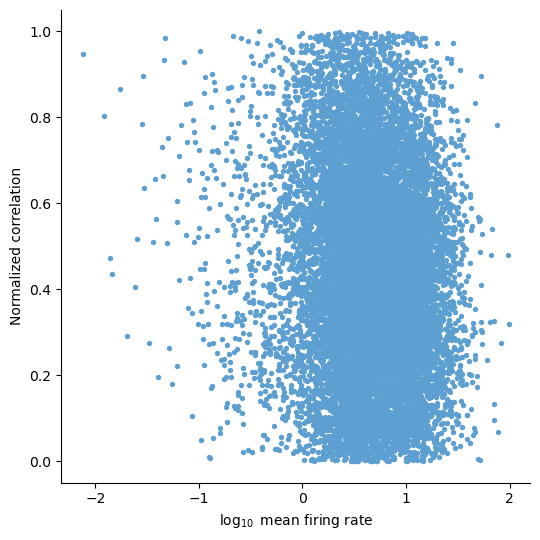

In [66]:
nc = np.asarray(encoding_results["alexnet"]["normalized_correlation"]).ravel()
plot_df = pd.DataFrame({"log10_mean_firing": mean_firing_rate, "norm_corr": nc})
plot_df = plot_df[np.isfinite(plot_df["log10_mean_firing"]) & np.isfinite(plot_df["norm_corr"])]
plot_df = plot_df[(plot_df["norm_corr"] >= 0) & (plot_df["norm_corr"] <= 1)]

fig, ax = plt.subplots(figsize=(5.5, 5.5))
sns.scatterplot(
    data=plot_df,
    x="log10_mean_firing",
    y="norm_corr",
    s=15,
    alpha=1,
    color="#5E9FD1",
    linewidth = 0,
    ax=ax,
)

ax.set_xlabel(r"$\log_{10}$ mean firing rate")
ax.set_ylabel("Normalized correlation")
sns.despine(ax=ax)
plt.tight_layout()

_plots_dir = os.path.join(encoding_dir, "scatter_plots")
os.makedirs(_plots_dir, exist_ok=True)
_pdf_path = os.path.join(_plots_dir, "mean_firing_rate_vs_alexnet_nc.pdf")
plt.savefig(_pdf_path, bbox_inches="tight")
plt.show()

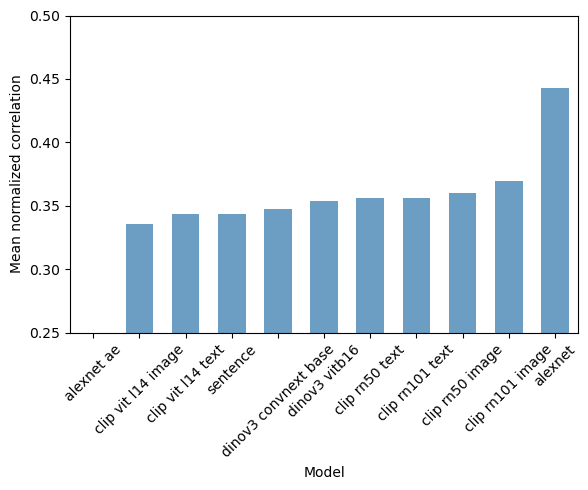

In [5]:
rows = []
for m, data in encoding_results.items():
    nc = np.asarray(data["normalized_correlation"]).ravel()
    valid = (nc >= 0) & (nc <= 1)
    nc_valid = nc[valid]
    mean_val = np.mean(nc_valid) if len(nc_valid) > 0 else np.nan
    rows.append((m, mean_val))
df_plot = pd.DataFrame(rows, columns=["model", "mean_norm_corr"])
order = df_plot.sort_values("mean_norm_corr")["model"].tolist()
fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(data=df_plot, x="model", y="mean_norm_corr", order=order, ax=ax, color='#5E9FD1', width=0.6)
ax.tick_params(axis="x", rotation=45)
ax.set_xlabel("Model")
ax.set_ylabel("Mean normalized correlation")
ax.set_ylim(0.25, 0.5)
plt.tight_layout()
# plots_dir = os.path.join(encoding_dir, "scatter_plots")
# os.makedirs(plots_dir, exist_ok=True)
# plt.savefig(os.path.join(plots_dir, "mean_norm_corr_boxplot.pdf"))
plt.show()

In [6]:
middle_areas = ['MF', 'MB', 'MO', 'LPP','CLC']
anterior_areas = ['AF', 'AB', 'AO','PITP','AMC']


In [32]:
from matplotlib.backends.backend_pdf import PdfPages

plots_dir = os.path.join(encoding_dir, "scatter_plots")
os.makedirs(plots_dir, exist_ok=True)

base_model_name = None
for name in encoding_results.keys():
    if "alexnet" in name.lower():
        base_model_name = name
        break

if base_model_name is None:
    raise ValueError("Base model alexnet not found in encoding_results keys")

all_pdf_path = os.path.join(plots_dir, "scatter_all_models.pdf")
with PdfPages(all_pdf_path) as pdf:
    for model_name, model_data in encoding_results.items():
        if model_name == base_model_name:
            continue
        x = encoding_results[base_model_name]["normalized_correlation"]
        y = model_data["normalized_correlation"]
        df = pd.DataFrame({"x": x, "y": y})
        sub_df = df[(df["x"] >= 0) & (df["x"] <= 1) & (df["y"] >= 0) & (df["y"] <= 1)]
        x_data = sub_df["x"].values
        y_data = sub_df["y"].values
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.scatter(x_data, y_data, s=1, alpha=1, color='#5E9FD1')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel(base_model_name)
        ax.set_ylabel(model_name)
        ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)
        a = np.sum(x_data * y_data) / np.sum(x_data**2)
        ax.plot([0, 1], [0, a], color="#EC6F7E", linewidth=1.5)
        ax.text(0.05, 0.95, f"slope={a:.3f}", transform=ax.transAxes, ha="left", va="top", color="#EC6F7E")
        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

region_pdf_path = os.path.join(plots_dir, "scatter_all_models_region.pdf")
with PdfPages(region_pdf_path) as pdf:
    for model_name, model_data in encoding_results.items():
        if model_name == base_model_name:
            continue

        x = encoding_results[base_model_name]["normalized_correlation"]
        y = model_data["normalized_correlation"]

        df = pd.DataFrame({
            "x": x,
            "y": y,
            "AREALABEL": unit_info["AREALABEL"].values
        })

        fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

        for ax, area_group, group_name in zip(axes, [middle_areas, anterior_areas], ["middle", "anterior"]):
            mask = df["AREALABEL"].apply(lambda s: any(str(s).startswith(a) for a in area_group))
            sub_df = df[mask]
            sub_df = sub_df[(sub_df["x"] >= 0) & (sub_df["x"] <= 1) & (sub_df["y"] >= 0) & (sub_df["y"] <= 1)]

            x_data = sub_df["x"].values
            y_data = sub_df["y"].values

            ax.scatter(x_data, y_data, s=1, alpha=1, color = '#5E9FD1')
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.set_xlabel(base_model_name)
            ax.set_ylabel(model_name)
            ax.set_title(group_name)

            ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)

            a = np.sum(x_data * y_data) / np.sum(x_data**2)
            ax.plot([0, 1], [0, a], color="#EC6F7E", linewidth=1.5)
            ax.text(0.05, 0.95, f"slope={a:.3f}", transform=ax.transAxes,
                    ha="left", va="top", color="#EC6F7E")

        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

In [10]:
from matplotlib.backends.backend_pdf import PdfPages

plots_dir = os.path.join(encoding_dir, "scatter_plots")
os.makedirs(plots_dir, exist_ok=True)

combined_pdf_path = os.path.join(plots_dir, "CLIP.pdf")
slope_records = []

with PdfPages(combined_pdf_path) as pdf:
        x_label = "CLIP RN101 Image"
        y_label = "CLIP RN101 Text"
        x = encoding_results['clip rn101 image']["normalized_correlation"]
        y = encoding_results['clip rn101 text']["normalized_correlation"]

        df = pd.DataFrame({
            "x": x,
            "y": y,
            "AREALABEL": unit_info["AREALABEL"].values
        })

        fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

        for ax, area_group, group_name in zip(axes, [middle_areas, anterior_areas], ["middle", "anterior"]):
            mask = df["AREALABEL"].apply(lambda s: any(str(s).startswith(a) for a in area_group))
            sub_df = df[mask]
            sub_df = sub_df[(sub_df["x"] >= 0) & (sub_df["x"] <= 1) & (sub_df["y"] >= 0) & (sub_df["y"] <= 1)]
            x_data = sub_df["x"].values
            y_data = sub_df["y"].values

            ax.scatter(x_data, y_data, s=1, alpha=1, color = '#5E9FD1')
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.set_xlabel(x_label)
            ax.set_ylabel(y_label)
            ax.set_title(group_name)

            ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)

            a = np.sum(x_data * y_data) / np.sum(x_data**2)
            ax.plot([0, 1], [0, a], color="#EC6F7E", linewidth=1.5)
            ax.text(0.05, 0.95, f"slope={a:.3f}", transform=ax.transAxes,
                    ha="left", va="top", color="#EC6F7E")

        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

        x_label = "CLIP RN50 Image"
        y_label = "CLIP RN50 Text"
        x = encoding_results['clip rn50 image']["normalized_correlation"]
        y = encoding_results['clip rn50 text']["normalized_correlation"]

        df = pd.DataFrame({
            "x": x,
            "y": y,
            "AREALABEL": unit_info["AREALABEL"].values
        })

        fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

        for ax, area_group, group_name in zip(axes, [middle_areas, anterior_areas], ["middle", "anterior"]):
            mask = df["AREALABEL"].apply(lambda s: any(str(s).startswith(a) for a in area_group))
            sub_df = df[mask]
            sub_df = sub_df[(sub_df["x"] >= 0) & (sub_df["x"] <= 1) & (sub_df["y"] >= 0) & (sub_df["y"] <= 1)]

            x_data = sub_df["x"].values
            y_data = sub_df["y"].values

            ax.scatter(x_data, y_data, s=1, alpha=1, color = '#5E9FD1')
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.set_xlabel(x_label)
            ax.set_ylabel(y_label)
            ax.set_title(group_name)

            ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)

            a = np.sum(x_data * y_data) / np.sum(x_data**2)
            ax.plot([0, 1], [0, a], color="#EC6F7E", linewidth=1.5)
            ax.text(0.05, 0.95, f"slope={a:.3f}", transform=ax.transAxes,
                    ha="left", va="top", color="#EC6F7E")

        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

        x_label = "CLIP ViT-L-14 Image"
        y_label = "CLIP ViT-L-14 Text"
        x = encoding_results['clip vit l14 image']["normalized_correlation"]
        y = encoding_results['clip vit l14 text']["normalized_correlation"]

        df = pd.DataFrame({
            "x": x,
            "y": y,
            "AREALABEL": unit_info["AREALABEL"].values
        })

        fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

        for ax, area_group, group_name in zip(axes, [middle_areas, anterior_areas], ["middle", "anterior"]):
            mask = df["AREALABEL"].apply(lambda s: any(str(s).startswith(a) for a in area_group))
            sub_df = df[mask]
            sub_df = sub_df[(sub_df["x"] >= 0) & (sub_df["x"] <= 1) & (sub_df["y"] >= 0) & (sub_df["y"] <= 1)]

            x_data = sub_df["x"].values
            y_data = sub_df["y"].values

            ax.scatter(x_data, y_data, s=1, alpha=1, color = '#5E9FD1')
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.set_xlabel(x_label)
            ax.set_ylabel(y_label)
            ax.set_title(group_name)

            ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)

            a = np.sum(x_data * y_data) / np.sum(x_data**2)
            ax.plot([0, 1], [0, a], color="#EC6F7E", linewidth=1.5)
            ax.text(0.05, 0.95, f"slope={a:.3f}", transform=ax.transAxes,
                    ha="left", va="top", color="#EC6F7E")

        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

In [26]:
def slope_no_intercept(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    valid = np.isfinite(x) & np.isfinite(y) & (x >= 0) & (x <= 1) & (y >= 0) & (y <= 1)
    x = x[valid]
    y = y[valid]
    if x.size == 0:
        return np.nan, 0
    denom = np.sum(x ** 2)
    if denom == 0:
        return np.nan, int(x.size)
    return float(np.sum(x * y) / denom), int(x.size)

base_model_name = None
for name in encoding_results.keys():
    if "alexnet" in name.lower():
        base_model_name = name
        break

if base_model_name is None:
    raise ValueError("Base model alexnet not found in encoding_results keys")

alex_x = encoding_results[base_model_name]["normalized_correlation"]
arealabel = unit_info["AREALABEL"].values

middle_mask = pd.Series(arealabel).apply(lambda s: any(str(s).startswith(a) for a in middle_areas)).values
anterior_mask = pd.Series(arealabel).apply(lambda s: any(str(s).startswith(a) for a in anterior_areas)).values
n_units = len(alex_x)
mid_idx = np.where(middle_mask)[0]
ant_idx = np.where(anterior_mask)[0]
n_sample = 5000
n_rep = 10
np.random.seed(42)

rows = []
for model_name, model_data in encoding_results.items():
    if model_name == base_model_name:
        continue
    y = np.asarray(model_data["normalized_correlation"]).ravel()
    for rep in range(n_rep):
        idx_all = np.random.choice(n_units, size=min(n_sample, n_units), replace=(n_units < n_sample))
        slope_all, _ = slope_no_intercept(alex_x[idx_all], y[idx_all])
        idx_mid = np.random.choice(len(mid_idx), size=min(n_sample, len(mid_idx)), replace=(len(mid_idx) < n_sample))
        slope_middle, _ = slope_no_intercept(alex_x[mid_idx[idx_mid]], y[mid_idx[idx_mid]])
        idx_ant = np.random.choice(len(ant_idx), size=min(n_sample, len(ant_idx)), replace=(len(ant_idx) < n_sample))
        slope_anterior, _ = slope_no_intercept(alex_x[ant_idx[idx_ant]], y[ant_idx[idx_ant]])
        rows.append({
            "model": model_name,
            "rep": rep,
            "slope_all": slope_all,
            "slope_middle": slope_middle,
            "slope_anterior": slope_anterior,
        })

slope_vs_alexnet_df = pd.DataFrame(rows)

out_csv = os.path.join(encoding_dir, "slope_vs_alexnet.csv")
slope_vs_alexnet_df.to_csv(out_csv, index=False)


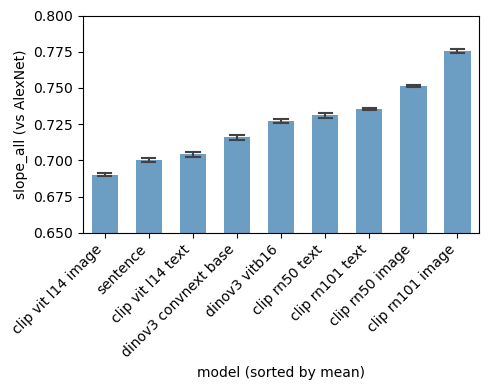

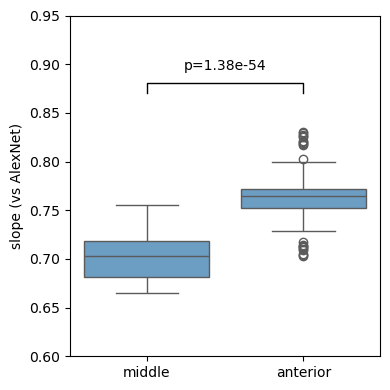

Saved: /media/ubuntu/sda/TrippleN/customize/encoding_analysis/scatter_plots/slope_all_bar_sorted.pdf
Saved: /media/ubuntu/sda/TrippleN/customize/encoding_analysis/scatter_plots/slope_middle_vs_anterior_boxplot.pdf
Paired t-test: t= -35.756490022138415 p= 1.3772723590576051e-54 n_pairs= 90


In [58]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plots_dir = os.path.join(encoding_dir, "scatter_plots")
os.makedirs(plots_dir, exist_ok=True)

order = slope_vs_alexnet_df.groupby('model')['slope_all'].mean().sort_values(ascending=True).index.tolist()

plt.figure(figsize=(5, 4))
sns.barplot(data=slope_vs_alexnet_df, x='model', y='slope_all', order=order, color='#5E9FD1', errorbar='se', width=0.6, capsize=0.3, err_kws={'linewidth': 1.5})
plt.ylim(0.65, 0.8)
plt.ylabel('slope_all (vs AlexNet)')
plt.xlabel('model (sorted by mean)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
bar_path = os.path.join(plots_dir, 'slope_all_bar_sorted.pdf')
plt.savefig(bar_path)
plt.show()

pair_df = slope_vs_alexnet_df[['model', 'rep', 'slope_middle', 'slope_anterior']].dropna()
x1 = pair_df['slope_middle'].values
x2 = pair_df['slope_anterior'].values

t_stat, p_val = stats.ttest_rel(x1, x2)

long_df = pd.DataFrame({
    'group': np.repeat(['middle', 'anterior'], repeats=[len(x1), len(x2)]),
    'slope': np.concatenate([x1, x2])
})
long_df_path = os.path.join(plots_dir, 'slope_middle_vs_anterior_boxplot_data.csv')
long_df.to_csv(long_df_path, index=False)
pair_df_path = os.path.join(plots_dir, 'slope_middle_vs_anterior_pairs.csv')
pair_df.to_csv(pair_df_path, index=False)
print('Saved:', long_df_path)
print('Saved:', pair_df_path)

plt.figure(figsize=(4, 4))
sns.boxplot(data=long_df, x='group', y='slope', color='#5E9FD1', showfliers=False)
#sns.stripplot(data=long_df, x='group', y='slope', color='black', size=4, alpha=0.7, jitter=0.08)
plt.ylim(0.6, 0.95)
plt.ylabel('slope (vs AlexNet)')
plt.xlabel('')

y_max = np.nanmax(long_df['slope'].values)
y_line = min(0.98, y_max + 0.05)
plt.plot([0, 0, 1, 1], [y_line-0.01, y_line, y_line, y_line-0.01], color='black', linewidth=1)
plt.text(0.5, y_line + 0.01, f'p={p_val:.3g}', ha='center', va='bottom')
plt.tight_layout()
box_path = os.path.join(plots_dir, 'slope_middle_vs_anterior_boxplot.pdf')
plt.savefig(box_path)
plt.show()

print('Saved:', bar_path)
print('Saved:', box_path)
n_pairs = len(pair_df)
print('Paired t-test: t=', t_stat, 'p=', p_val, 'n_pairs=', n_pairs)

In [61]:
from scipy.io import loadmat
from scipy.stats import friedmanchisquare, wilcoxon

psth_path = '/media/ubuntu/sda/TrippleN/customize/aggregate_response/all_subjects_psth.npy'
psth_data = np.load(psth_path, mmap_mode='r')
n_neurons = psth_data.shape[0]
n_stimuli = psth_data.shape[1]
n_time = psth_data.shape[2]
best_r_time1 = unit_info['best_r_time1'].values
best_r_time2 = unit_info['best_r_time2'].values
neuron_responses = np.zeros((n_neurons, n_stimuli), dtype=np.float32)
for neuron_idx in range(n_neurons):
    start_time = int(best_r_time1[neuron_idx])
    end_time = int(best_r_time2[neuron_idx])
    if start_time < 0:
        start_time = 0
    if end_time > n_time:
        end_time = n_time
    if end_time <= start_time:
        mid_time = n_time // 2
        start_time = max(0, mid_time - 5)
        end_time = min(n_time, mid_time + 5)
    psth_neuron = psth_data[neuron_idx, :n_stimuli, start_time:end_time]
    neuron_responses[neuron_idx] = np.mean(psth_neuron, axis=1)

responses_1000 = neuron_responses[:, :1000]
n_units = responses_1000.shape[0]
rmin = responses_1000.min(axis=1, keepdims=True)
rmax = responses_1000.max(axis=1, keepdims=True)
R = 2 * (responses_1000.astype(np.float64) - rmin) / (rmax - rmin + 1e-10) - 1

cluster_info = loadmat('/media/ubuntu/sda/TrippleN/ClusInfo.mat')['Cluster_idx']
cluster_flat = np.asarray(cluster_info).flatten()
cluster_ids = np.unique(cluster_flat)
n_clusters = len(cluster_ids)
SI_clusters = np.zeros((n_units, n_clusters))
for j in range(n_clusters):
    mask_c = (cluster_flat == cluster_ids[j])
    mask_n = ~mask_c
    m_cat = R[:, mask_c].mean(axis=1)
    m_non = R[:, mask_n].mean(axis=1)
    v_cat = R[:, mask_c].var(axis=1)
    v_non = R[:, mask_n].var(axis=1)
    SI_clusters[:, j] = (m_cat - m_non) / np.sqrt(0.5 * (v_cat + v_non) + 1e-10)

unit_info_tuning = unit_info.copy()
for j in range(n_clusters):
    unit_info_tuning[f'C{j}_selectivity'] = (SI_clusters[:, j] > 0.3).astype(int)
n_cluster_sel = sum(unit_info_tuning[f'C{j}_selectivity'] for j in range(n_clusters))
unit_info_tuning['cluster_tuning_type'] = 'multi_tuning'
unit_info_tuning.loc[n_cluster_sel == 0, 'cluster_tuning_type'] = 'no_tuning'
unit_info_tuning.loc[n_cluster_sel == 1, 'cluster_tuning_type'] = 'single_tuning'

single_mask = (unit_info_tuning['cluster_tuning_type'] == 'single_tuning').values
multi_mask = (unit_info_tuning['cluster_tuning_type'] == 'multi_tuning').values
no_mask = (unit_info_tuning['cluster_tuning_type'] == 'no_tuning').values

model_names = list(encoding_results.keys())
n_models = len(model_names)
mean_corr_matrix = np.zeros((3, n_models))
tuning_labels = ['single', 'multi', 'no-tuning']
for j, model_name in enumerate(model_names):
    data = encoding_results[model_name]
    corr = np.asarray(data['normalized_correlation']).ravel()
    valid = (corr >= 0) & (corr <= 1)
    v_s = corr[single_mask & valid]
    v_m = corr[multi_mask & valid]
    v_n = corr[no_mask & valid]
    mean_corr_matrix[0, j] = np.mean(v_s) if len(v_s) > 0 else np.nan
    mean_corr_matrix[1, j] = np.mean(v_m) if len(v_m) > 0 else np.nan
    mean_corr_matrix[2, j] = np.mean(v_n) if len(v_n) > 0 else np.nan

valid_cols = np.isfinite(mean_corr_matrix).all(axis=0)
if valid_cols.sum() >= 3:
    s_s, s_m, s_n = mean_corr_matrix[0][valid_cols], mean_corr_matrix[1][valid_cols], mean_corr_matrix[2][valid_cols]
    stat_friedman, p_friedman = friedmanchisquare(s_s, s_m, s_n)
    _, p_sm = wilcoxon(s_s, s_m, alternative='two-sided')
    _, p_sn = wilcoxon(s_s, s_n, alternative='two-sided')
    _, p_mn = wilcoxon(s_m, s_n, alternative='two-sided')
    n_comp = 3
    p_sm_adj = min(1, p_sm * n_comp)
    p_sn_adj = min(1, p_sn * n_comp)
    p_mn_adj = min(1, p_mn * n_comp)
    print('Mean norm. corr matrix shape (3 tuning types x n_models):', mean_corr_matrix.shape)
    print('Friedman (3 conditions differ): stat=%.4f, p=%.4e' % (stat_friedman, p_friedman))
    print('Pairwise Wilcoxon (Bonferroni x3): single vs multi p=%.4e, single vs no p=%.4e, multi vs no p=%.4e' % (p_sm_adj, p_sn_adj, p_mn_adj))
else:
    p_friedman = np.nan
    p_sm_adj = p_sn_adj = p_mn_adj = np.nan
    print('Mean norm. corr matrix shape (3 tuning types x n_models):', mean_corr_matrix.shape)
    print('Too few valid models for Friedman test.')
df_tuning_display = pd.DataFrame(mean_corr_matrix, index=tuning_labels, columns=model_names)
print(df_tuning_display.to_string())

Mean norm. corr matrix shape (3 tuning types x n_models): (3, 10)
Friedman (3 conditions differ): stat=20.0000, p=4.5400e-05
Pairwise Wilcoxon (Bonferroni x3): single vs multi p=5.8594e-03, single vs no p=5.8594e-03, multi vs no p=5.8594e-03
            alexnet  clip rn101 image  clip rn101 text  clip rn50 image  clip rn50 text  clip vit l14 image  clip vit l14 text  dinov3 convnext base  dinov3 vitb16  sentence
single     0.451492          0.375407         0.359980         0.369295        0.359988            0.342484           0.347764              0.350436       0.360898  0.343100
multi      0.430926          0.359843         0.348286         0.349842        0.350139            0.325126           0.334919              0.341607       0.344485  0.338349
no-tuning  0.462258          0.390743         0.374820         0.373815        0.367633            0.357142           0.360097              0.362049       0.371061  0.360943


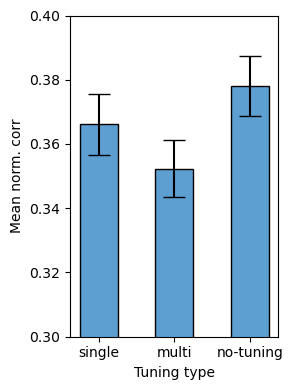

In [68]:
def _p_to_star(p):
    if not np.isfinite(p):
        return 'n.s.'
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'n.s.'

y = np.nanmean(mean_corr_matrix, axis=1)
n_valid = np.isfinite(mean_corr_matrix).sum(axis=1)
yerr = np.nanstd(mean_corr_matrix, axis=1) / np.sqrt(np.maximum(n_valid, 1))
x_pos = np.arange(3)
fig, ax = plt.subplots(figsize=(3, 4))
bars = ax.bar(x_pos, y, yerr=yerr, capsize=8, width=0.5, color='#5E9FD1', edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(tuning_labels)
ax.set_ylabel('Mean norm. corr')
ax.set_xlabel('Tuning type')
y_max = (y + yerr).max()
step = y_max * 0.06
ax.set_ylim(0.3, 0.4)
h = step * 0.8
plt.tight_layout()
plt.savefig(os.path.join(encoding_dir, 'encoding_by_tuning_type_all_models.pdf'), bbox_inches='tight')
plt.show()

In [72]:
alexnet_key = None
for name in encoding_results.keys():
    if 'alexnet' in name.lower():
        alexnet_key = name
        break
if alexnet_key is not None:
    alexnet_nc = np.asarray(encoding_results[alexnet_key]['normalized_correlation']).ravel()
    if len(alexnet_nc) == len(unit_info_tuning):
        unit_info_tuning['alexnet_nc'] = alexnet_nc
        out_path = os.path.join(encoding_dir, 'unit_info_tuning_with_alexnet.pkl')
        unit_info_tuning.to_pickle(out_path)
        print('已保存 unit_info_tuning（含 alexnet_nc）至', out_path)
    else:
        print('alexnet normalized_correlation 长度(%d) 与 unit_info_tuning(%d) 不一致，未保存' % (len(alexnet_nc), len(unit_info_tuning)))
else:
    print('未找到 alexnet 的 encoding 结果，未保存')

已保存 unit_info_tuning（含 alexnet_nc）至 /media/ubuntu/sda/TrippleN/customize/encoding_analysis/unit_info_tuning_with_alexnet.pkl


#### Session analysis

In [21]:
unit_info_tuning = pd.read_pickle("/media/ubuntu/sda/TrippleN/customize/encoding_analysis/unit_info_tuning_with_alexnet.pkl")
n_before = len(unit_info_tuning)
unit_info_tuning = unit_info_tuning.loc[
    (unit_info_tuning["alexnet_nc"] >= 0) & (unit_info_tuning["alexnet_nc"] <= 1)
].copy()
print("units:", n_before, "->", len(unit_info_tuning), "(alexnet_nc in [0, 1])")

units: 15652 -> 14473 (alexnet_nc in [0, 1])


saved: /media/ubuntu/sda/TrippleN/customize/encoding_analysis/alexnet_nc_by_session_id_boxplot_summary.csv
saved: /media/ubuntu/sda/TrippleN/customize/encoding_analysis/alexnet_nc_by_session_id_boxplot_units.csv


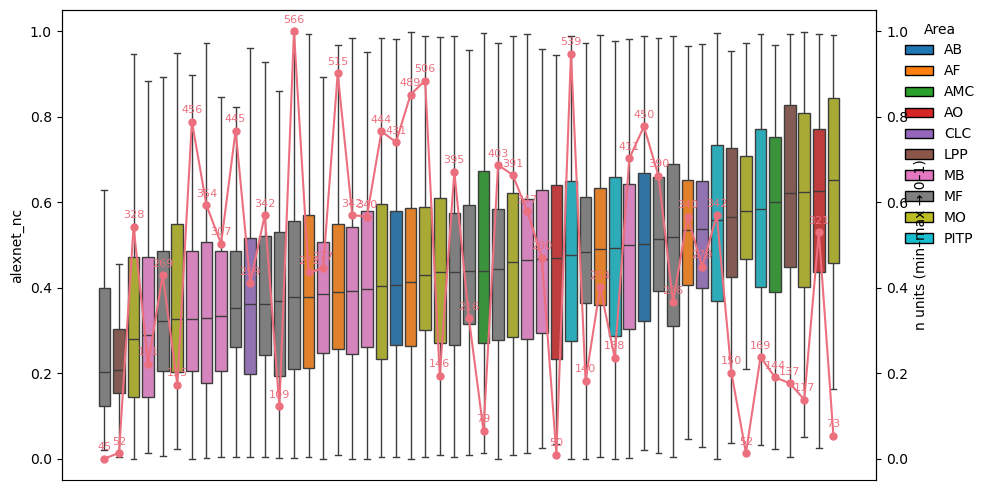

In [29]:
_tuning_plot_dir = "/media/ubuntu/sda/TrippleN/customize/encoding_analysis"
os.makedirs(_tuning_plot_dir, exist_ok=True)

col = "session_id"
df = unit_info_tuning
order = df.groupby(col)["alexnet_nc"].median().sort_values().index.tolist()
counts = df.groupby(col).size().reindex(order, fill_value=0)
cmin, cmax = counts.min(), counts.max()
if cmax > cmin:
    scaled = (counts - cmin) / (cmax - cmin)
else:
    scaled = pd.Series(0.5, index=counts.index)

_g = df.groupby(col)["alexnet_nc"]
plot_summary = pd.DataFrame(
    {
        col: order,
        "n_units": counts.values.astype(int),
        "n_units_scaled_minmax": scaled.reindex(order).values.astype(float),
        "alexnet_nc_median": _g.median().reindex(order).values,
        "alexnet_nc_q25": _g.quantile(0.25).reindex(order).values,
        "alexnet_nc_q75": _g.quantile(0.75).reindex(order).values,
    }
)
csv_summary = os.path.join(_tuning_plot_dir, "alexnet_nc_by_session_id_boxplot_summary.csv")
plot_summary.to_csv(csv_summary, index=False)
_unit_cols = [c for c in [col, "alexnet_nc", "Area", "subject", "SesIdx", "AREALABEL"] if c in df.columns]
csv_units = os.path.join(_tuning_plot_dir, "alexnet_nc_by_session_id_boxplot_units.csv")
df[_unit_cols].to_csv(csv_units, index=False)
print("saved:", csv_summary)
print("saved:", csv_units)

w_sess = max(16, len(order) * 0.8)
fig, ax = plt.subplots(figsize=(10, 5))
import matplotlib.patches as mpatches

if "Area" in df.columns:
    sess_area = (
        df[[col, "Area"]]
        .dropna(subset=["Area"])
        .groupby(col)["Area"]
        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
    )
    area_order = sorted(sess_area.dropna().unique().tolist())
    area_palette = dict(zip(area_order, sns.color_palette("tab10", n_colors=len(area_order))))
    session_palette = {s: area_palette.get(sess_area.get(s), "#5E9FD1") for s in order}
    sns.boxplot(
        data=df,
        x=col,
        y="alexnet_nc",
        order=order,
        palette=session_palette,
        ax=ax,
        showfliers=False,
        width=0.8,
    )
    legend_handles = [
        mpatches.Patch(facecolor=area_palette[a], edgecolor="black", label=str(a))
        for a in area_order
    ]
    if legend_handles:
        ax.legend(handles=legend_handles, title="Area", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
else:
    sns.boxplot(data=df, x=col, y="alexnet_nc", order=order, ax=ax, color="#5E9FD1", showfliers=False, width=0.8)

ax.set_xlabel("")
ax.tick_params(axis="x", labelbottom=False, bottom=False)
ax.spines["bottom"].set_visible(False)

ax.set_ylim(-0.05, 1.05)
yt = np.linspace(0, 1, 6)
ax.set_yticks(yt)
ax.set_ylabel("alexnet_nc")

ax2 = ax.twinx()
xpos = np.asarray(ax.get_xticks())[: len(order)]
ax2.plot(xpos, scaled.values, color="#EC6F7E", marker="o", linewidth=1.5, markersize=5)
ax2.set_ylim(-0.05, 1.05)
ax2.set_yticks(yt)
ax2.set_ylabel("n units (min–max → 0–1)")
for xi, sc, n in zip(xpos, scaled.values, counts.values):
    ax2.annotate(
        str(int(n)),
        xy=(xi, float(sc)),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        color="#EC6F7E",
    )

plt.tight_layout()
plt.savefig(os.path.join(_tuning_plot_dir, "alexnet_nc_by_session_id_boxplot.pdf"), bbox_inches="tight")
plt.show()


saved: /media/ubuntu/sda/TrippleN/customize/encoding_analysis/alexnet_nc_by_Area_boxplot_summary.csv
saved: /media/ubuntu/sda/TrippleN/customize/encoding_analysis/alexnet_nc_by_Area_boxplot_units.csv


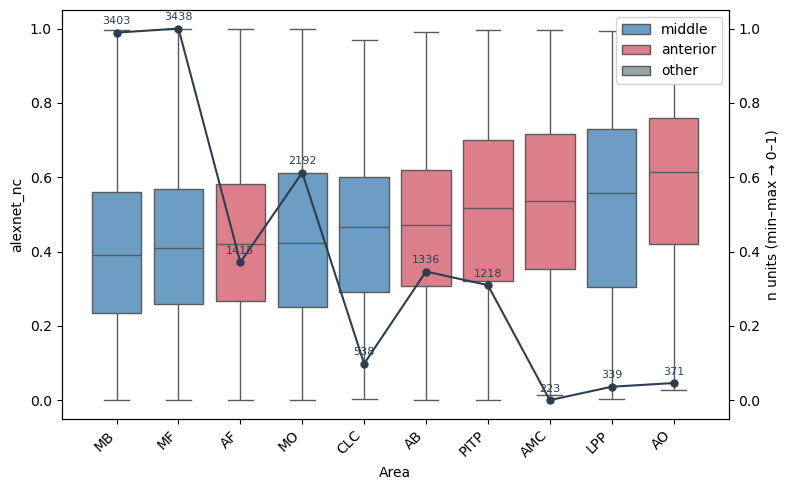

In [19]:
middle_areas = ["MF", "MB", "MO", "LPP", "CLC"]
anterior_areas = ["AF", "AB", "AO", "PITP", "AMC"]
COLOR_MIDDLE = "#5E9FD1"
COLOR_ANTERIOR = "#EC6F7E"
COLOR_OTHER = "#95A5A6"

col = "Area"
df = unit_info_tuning
order = df.groupby(col)["alexnet_nc"].median().sort_values().index.tolist()
counts = df.groupby(col).size().reindex(order, fill_value=0)
cmin, cmax = counts.min(), counts.max()
if cmax > cmin:
    scaled = (counts - cmin) / (cmax - cmin)
else:
    scaled = pd.Series(0.5, index=counts.index)

def _area_region(a):
    s = str(a)
    if s in middle_areas:
        return "middle"
    if s in anterior_areas:
        return "anterior"
    return "other"

df_area_plot = df.copy()
df_area_plot["_region"] = df_area_plot[col].map(_area_region)

_g = df.groupby(col)["alexnet_nc"]
plot_summary = pd.DataFrame(
    {
        col: order,
        "region": [_area_region(a) for a in order],
        "n_units": counts.values.astype(int),
        "n_units_scaled_minmax": scaled.reindex(order).values.astype(float),
        "alexnet_nc_median": _g.median().reindex(order).values,
        "alexnet_nc_q25": _g.quantile(0.25).reindex(order).values,
        "alexnet_nc_q75": _g.quantile(0.75).reindex(order).values,
    }
)
_tuning_plot_dir = "/media/ubuntu/sda/TrippleN/customize/encoding_analysis"
os.makedirs(_tuning_plot_dir, exist_ok=True)
csv_summary = os.path.join(_tuning_plot_dir, "alexnet_nc_by_Area_boxplot_summary.csv")
plot_summary.to_csv(csv_summary, index=False)
_unit_cols = [c for c in [col, "alexnet_nc", "_region", "session_id", "subject", "SesIdx", "AREALABEL"] if c in df_area_plot.columns]
csv_units = os.path.join(_tuning_plot_dir, "alexnet_nc_by_Area_boxplot_units.csv")
df_area_plot[_unit_cols].to_csv(csv_units, index=False)
print("saved:", csv_summary)
print("saved:", csv_units)

w_area = max(8, len(order) * 0.35)
fig, ax = plt.subplots(figsize=(w_area, 5))
sns.boxplot(
    data=df_area_plot,
    x=col,
    y="alexnet_nc",
    order=order,
    hue="_region",
    hue_order=["middle", "anterior", "other"],
    palette={"middle": COLOR_MIDDLE, "anterior": COLOR_ANTERIOR, "other": COLOR_OTHER},
    dodge=False,
    showfliers=False,
    ax=ax,
)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ["middle", "anterior", "other"], title="", loc="upper right", framealpha=0.9)
ax.set_xlabel("Area")
ax.tick_params(axis="x", rotation=45)
plt.setp(ax.get_xticklabels(), ha="right")

ax.set_ylim(-0.05, 1.05)
yt = np.linspace(0, 1, 6)
ax.set_yticks(yt)
ax.set_ylabel("alexnet_nc")

ax2 = ax.twinx()
xpos = np.asarray(ax.get_xticks())[: len(order)]
LINE_COUNT = "#2C3E50"
ax2.plot(xpos, scaled.values, color=LINE_COUNT, marker="o", linewidth=1.5, markersize=5)
ax2.set_ylim(-0.05, 1.05)
ax2.set_yticks(yt)
ax2.set_ylabel("n units (min–max → 0–1)")
for xi, sc, n in zip(xpos, scaled.values, counts.values):
    ax2.annotate(
        str(int(n)),
        xy=(xi, float(sc)),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        color=LINE_COUNT,
    )

plt.tight_layout()
plt.savefig(os.path.join(_tuning_plot_dir, "alexnet_nc_by_Area_boxplot.pdf"), bbox_inches="tight")
plt.show()


In [ ]:
unit_info_tuning